In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3")

Mounted at /content/drive


In [3]:
print(os.getcwd())

/content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3


In [5]:
from huggingface_hub import login
login()

In [4]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True


In [ ]:
!git clone https://github.com/facebookresearch/sam3.git

fatal: destination path 'sam3' already exists and is not an empty directory.
Obtaining file:///content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3/sam3
ERROR: file:///content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3/sam3 does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [5]:
!pip install -e .

Obtaining file:///content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 127.9 MB/s eta 0:00:00
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15935 sha256=c1e2ae4c1ef23cd51b7b726333eacd5e8ea3567c33286ffb1d6a0e634c773ce6
  Stored in directory: /tmp/pip-ephem-wheel-cache-vvli_sot/wheels/79/02/a7/d5dbd045fe3559bf701d184df822ead2a4258eae7599448d4b
  Created whee

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

In [2]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [3]:
os.chdir("/content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3/sam3")

In [6]:
bpe_path = f"assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

In [77]:
image_path = f"/content/drive/MyDrive/Jersey_Detection/images/1L5A7414-10-15.jpg"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)

found 8 object(s)


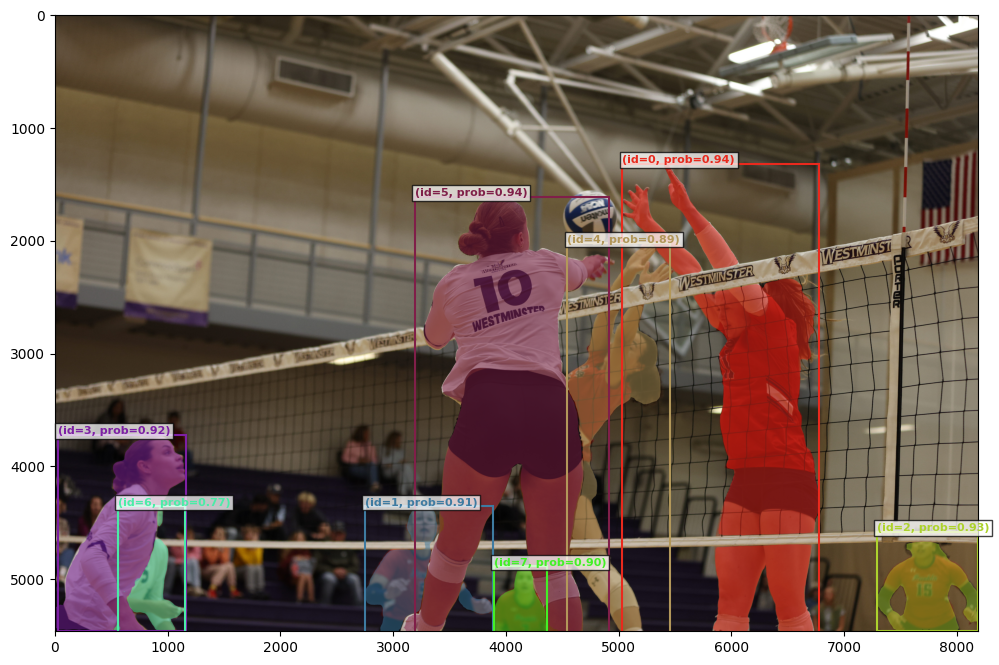

In [78]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="Athletes")

img0 = Image.open(image_path)
plot_results(img0, inference_state)

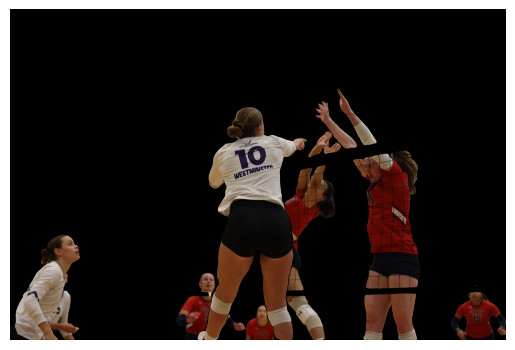

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
import matplotlib.pyplot as plt
from google.colab import files
masks, boxes, scores = inference_state["masks"], inference_state["boxes"], inference_state["scores"]
image_array = np.array(img0)
full_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
for mask in masks:
  bool_mask = mask.cpu().numpy().astype(np.uint8)
  mask_squeeze = np.squeeze(bool_mask, axis = 0)
  temp_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
  for i in range(3):
    temp_mask[:,:, i] = mask_squeeze
  full_mask += (image_array * temp_mask)
result_img = Image.fromarray(full_mask.astype(np.uint8))
plt.imshow(result_img)
plt.axis('off')
plt.show()
result_img.save("test_img.jpg")
files.download("test_img.jpg")

In [7]:
import segment
import importlib
from pathlib import Path
image_folder = Path("/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/jersey numbers")
image_files = [str(f) for f in image_folder.iterdir() if f.is_file()]

ModuleNotFoundError: No module named 'segment'